# 04 — Baseline Model

This notebook trains TF-IDF vectorizer combined with a Logistic
Regression classifier.

The official metric for this project is **macro-F1**

Only `data/processed/train.csv` (fitting) and `data/processed/val.csv`
(hyperparameter selection and reporting)

In [1]:
import sys
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config, evaluate, model

train_df = pd.read_csv(config.PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(config.PROCESSED_DIR / "val.csv")

train_df.shape, val_df.shape

((4257, 4), (752, 4))

## 1. Feature representation and model

For the text representation, I use **TF-IDF** instead of simple word counts. TF-IDF gives less weight to words that appear in almost every tweet, such as common function words, and more weight to words that are more specific to an individual tweet. This makes it easier for the model to distinguish between the two classes.

As the classifier, I use **Logistic Regression**. It is a common and easy-to-understand baseline model for text classification. It also provides class probabilities, which can be useful later when analysing incorrect predictions.

The dataset is imbalanced, with around **66% OTHER** and **34% OFFENSE**. Since the official evaluation metric is macro-F1 and therefore treats both classes equally, I use `class_weight="balanced"` in `src/model.py`. This gives more weight to the less frequent class during training and prevents the model from focusing too strongly on the majority class.


## 2. Hyperparameter search

Two hyperparameters are tuned, both selected only by **macro-F1 on
`val.csv`**:

- the TF-IDF **n-gram range**: unigrams only, or unigrams + bigrams
  (`config.BASELINE_NGRAM_RANGES`)
- the Logistic Regression **regularization strength `C`**:
  `[0.01, 0.1, 1.0, 10.0]` (`config.BASELINE_C_GRID`)

For each n-gram range the vectorizer is fit once on `train.csv` and reused
for every value of `C`, to avoid redundant vectorization. Each (n-gram
range, C) combination is scored once, and its fitted vectorizer/model are
kept so the winning combination does not need to be retrained.

In [ ]:
results = []
fitted_models = {}

for ngram_range in config.BASELINE_NGRAM_RANGES:
    tf_idf = model.build_vectorizer(ngram_range=ngram_range)
    X_train = tf_idf.fit_transform(train_df["text"])
    X_val = tf_idf.transform(val_df["text"])

    for C in config.BASELINE_C_GRID:
        clf = model.train_logistic_regression(
            X_train, train_df["label"], C=C, seed=config.SEED
        )
        val_preds = clf.predict(X_val)
        score = evaluate.macro_f1(val_df["label"], val_preds)

        results.append({"ngram_range": ngram_range, "C": C, "val_macro_f1": score})
        fitted_models[(ngram_range, C)] = (tf_idf, clf)

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
results_df

,ngram_range,C,val_macro_f1
0,"(1, 2)",10.00,0.696791
1,"(1, 1)",10.00,0.687889
2,"(1, 1)",1.00,0.687455
3,"(1, 2)",1.00,0.676522
4,"(1, 2)",0.10,0.666644
5,"(1, 1)",0.10,0.643718
6,"(1, 1)",0.01,0.629615
7,"(1, 2)",0.01,0.620187


The best-performing combination, by validation macro-F1, is used as the
final baseline model.

In [3]:
best_row = results_df.iloc[0]
best_ngram_range = tuple(best_row["ngram_range"])
best_C = best_row["C"]
best_vectorizer, best_clf = fitted_models[(best_ngram_range, best_C)]

print(f"best ngram_range={best_ngram_range}, C={best_C}, val macro-F1={best_row['val_macro_f1']:.4f}")

best ngram_range=(1, 2), C=10.0, val macro-F1=0.6968


## 3. Final validation evaluation

The selected baseline is evaluated in full on `val.csv`: macro-F1, the
per-class precision/recall/F1 report, and the confusion matrix. This is
still model *selection and reporting* on the validation set, not a
test-set evaluation.

macro-F1: 0.6968

              precision    recall  f1-score   support

       OTHER       0.79      0.81      0.80       499
     OFFENSE       0.60      0.58      0.59       253

    accuracy                           0.73       752
   macro avg       0.70      0.70      0.70       752
weighted avg       0.73      0.73      0.73       752



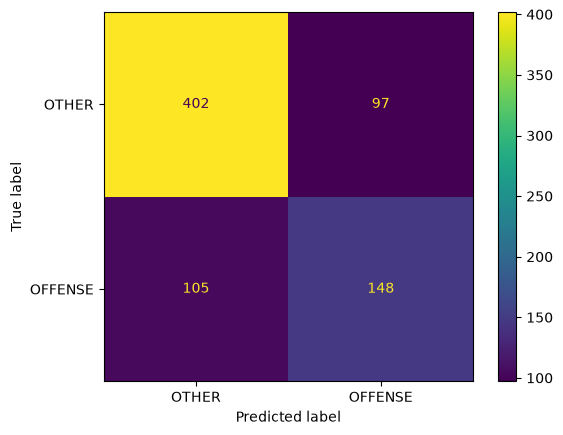

In [4]:
val_preds = best_clf.predict(best_vectorizer.transform(val_df["text"]))
final_metrics = evaluate.evaluate_predictions(val_df["label"], val_preds)

print(f"macro-F1: {final_metrics['macro_f1']:.4f}\n")
print(final_metrics["report"])

ConfusionMatrixDisplay(
    confusion_matrix=final_metrics["confusion_matrix"],
    display_labels=["OTHER", "OFFENSE"],
).plot()
plt.show()

## 4. Error analysis

For a short error analysis, I look at a few incorrectly classified examples from the validation set. I separate them into **false negatives**, where an offensive tweet was predicted as OTHER, and **false positives**, where a tweet from the OTHER class was predicted as OFFENSE.

This gives a quick impression of the kinds of mistakes the model makes. It also helps check whether the errors are understandable or ambiguous cases, rather than being caused by an obvious problem in the model or the data.


In [5]:
val_results = val_df[["text", "label"]].copy()
val_results["pred"] = val_preds

false_negatives = val_results[(val_results["label"] == "OFFENSE") & (val_results["pred"] == "OTHER")]
false_positives = val_results[(val_results["label"] == "OTHER") & (val_results["pred"] == "OFFENSE")]

print(f"false negatives: {len(false_negatives)}, false positives: {len(false_positives)}")

false negatives: 105, false positives: 97

In [6]:
false_negatives.sample(n=min(5, len(false_negatives)), random_state=config.SEED)

,text,label,pred
216,@USER @USER Soweit mir bekannt ist das Wort Mu...,OFFENSE,OTHER
429,@USER @USER Ich hoffe das Merkel dort gesteini...,OFFENSE,OTHER
427,Was ist denn mit unseren Generälen los ??Bei d...,OFFENSE,OTHER
361,@USER Hier über den Prozess gegen #NPD-#Neonaz...,OFFENSE,OTHER
312,@USER Die beiden UNDEUTSCHEN Ausländerinnen kö...,OFFENSE,OTHER


In [7]:
false_positives.sample(n=min(5, len(false_positives)), random_state=config.SEED)

,text,label,pred
558,Auch durch eure Zensur in Deutschland werdet i...,OTHER,OFFENSE
382,@USER @USER 😜Frauen haben (wie auch Männer!) 3...,OTHER,OFFENSE
720,@USER @USER Niemals...die Deutschen lieben die...,OTHER,OFFENSE
206,"Sachtma, soll ich zum Türken oder zum Chinesen...",OTHER,OFFENSE
670,@USER @USER Selbstverständlich. There is no ba...,OTHER,OFFENSE


## 5. Save baseline artifacts

The fitted vectorizer and classifier are saved to `models/` so later
notebooks (robustness evaluation on `data/perturbed/`, and the final
test-set report) can load this exact baseline without retraining. The
hyperparameter search table and final validation metrics are saved to
`results/` for the project report.

In [8]:
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_vectorizer, config.MODELS_DIR / "baseline_tfidf_vectorizer.joblib")
joblib.dump(best_clf, config.MODELS_DIR / "baseline_logreg.joblib")

results_df.to_csv(config.RESULTS_DIR / "baseline_grid_search.csv", index=False)

with open(config.RESULTS_DIR / "baseline_val_report.txt", "w") as f:
    f.write(f"best ngram_range={best_ngram_range}, C={best_C}\n\n")
    f.write(f"macro-F1: {final_metrics['macro_f1']:.4f}\n\n")
    f.write(final_metrics["report"])

print("saved baseline_tfidf_vectorizer.joblib, baseline_logreg.joblib, baseline_grid_search.csv, baseline_val_report.txt")

saved baseline_tfidf_vectorizer.joblib, baseline_logreg.joblib, baseline_grid_search.csv, baseline_val_report.txt
